## Gaussian Blue Noise Sampling

In this notebook, we generate samples of Gaussian Blue Noise and use that to count linear regions in neural networks. We can then compare the variance properties to the simple iid random sampling (binomial point process).

#### Imports

Standard imports:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import importlib

Quasi-Monte Carlo libraries:

In [10]:
from matplotlib.collections import PatchCollection
from scipy.stats import qmc

Gaussian Blue Noise files:

In [386]:
import spectrum_nd
import gbn_bounded_current
import gbn_toroidal_current
import gbn_toroidal_current_2

In [471]:
importlib.reload(gbn_bounded_current)
importlib.reload(spectrum_nd)
importlib.reload(gbn_toroidal_current_2)

<module 'gbn_toroidal_current_2' from '/Users/gautamchauhan/Desktop/MSc Project Code/code/gbn_toroidal_current_2.py'>

#### Bounded Blue Noise in 2D:

Generate 100 blue noise point sets with 4000 points each:

In [18]:
point_sets = 100
size = 1000
dimensions = 2

In [19]:
blue_noise_points = np.empty((point_sets,size,dimensions))

for i in range(point_sets):
    result = gbn_bounded_current.sample_bounded_gbn(
        point_count=1000,
        dims=2,
        bounds=[[-1,1] for i in range(2)],
        sigma=1,
        iterations=10000,
        seed=i,
    )
    points = result.points
    blue_noise_points[i,:,:] = points

Plot the first set of 2D blue noise points:

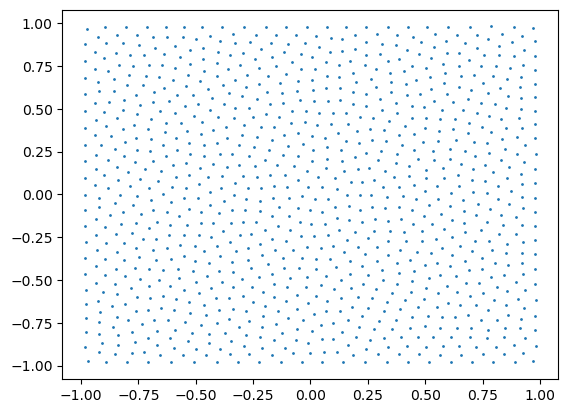

In [20]:
plt.scatter(points[:,0],points[:,1],s=1)

Generate power spectra for each point set and average over the different spectra. Plot the radial component of the power spectrum:

In [21]:
spectra = []
for i in range(point_sets):
    spectrum = spectrum_nd.power_spectrum(blue_noise_points[i,:,:],size=32,device="auto")
    spectra.append(spectrum)

In [31]:
diagonal_magnitudes = [np.sqrt(2*i**2) for i in range(32)]
diagonal_magnitudes = diagonal_magnitudes/max(diagonal_magnitudes)

radial_spectra = np.empty((point_sets,32))
for i in range(point_sets):
    radial_spectra[i,:] = np.array([spectra[i][j,j] for j in range(32,64)])
mean_spectrum = np.mean(radial_spectra,axis=0)

Text(0, 0.5, 'Amplitude')

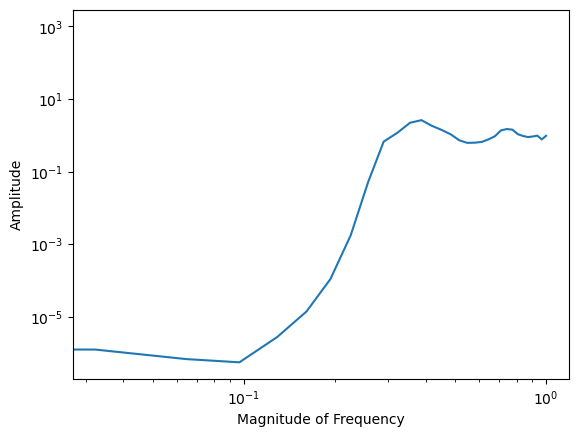

In [32]:
plt.loglog(diagonal_magnitudes,mean_spectrum)
plt.xlabel("Magnitude of Frequency")
plt.ylabel("Amplitude")

#### Bounded Blue Noise in 3D:

In [34]:
dimensions=3
blue_noise_points_3D = np.empty((point_sets,size,dimensions))

for i in range(point_sets):
    result = gbn_bounded_current.sample_bounded_gbn(
        point_count=1000,
        dims=3,
        bounds=[[-1,1] for i in range(3)],
        sigma=1,
        iterations=10000,
        seed=i,
    )
    points = result.points
    blue_noise_points_3D[i,:,:] = points

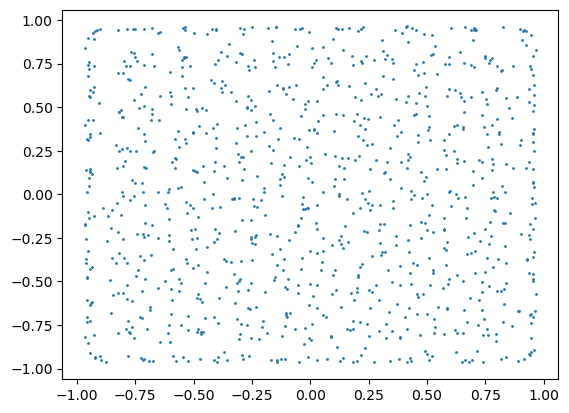

In [35]:
plt.scatter(points[:,0],points[:,1],s=1)

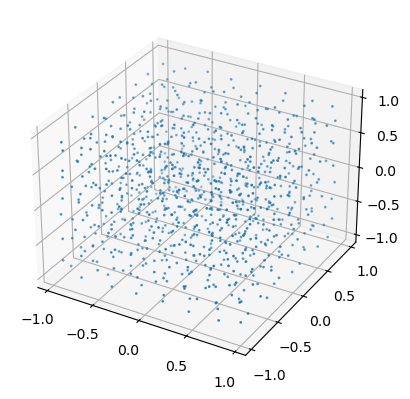

In [36]:
fig = plt.figure()
axs = fig.add_subplot(projection="3d")
axs.scatter(points[:,0],points[:,1],points[:,2],s=1)

In [38]:
spectra = []
for i in range(point_sets):
    spectrum = spectrum_nd.power_spectrum(blue_noise_points_3D[i,:,:],size=32,device="auto")
    spectra.append(spectrum)

In [41]:
diagonal_magnitudes = [np.sqrt(3*i**2) for i in range(32)]
diagonal_magnitudes = diagonal_magnitudes/max(diagonal_magnitudes)

radial_spectra = np.empty((point_sets,32))
for i in range(point_sets):
    radial_spectra[i,:] = np.array([spectra[i][j,j,j] for j in range(32,64)])
mean_spectrum = np.mean(radial_spectra,axis=0)

Text(0, 0.5, 'Amplitude')

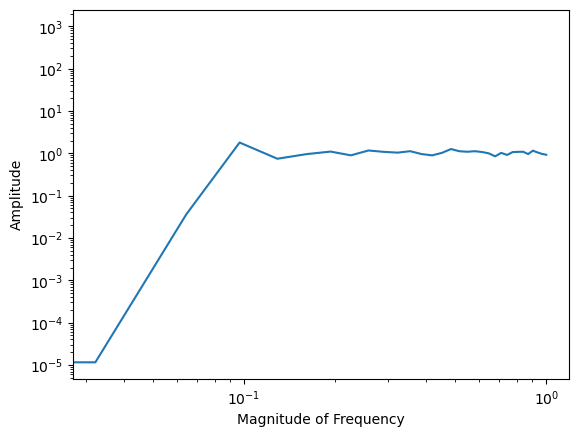

In [42]:
plt.loglog(diagonal_magnitudes,mean_spectrum)
plt.xlabel("Magnitude of Frequency")
plt.ylabel("Amplitude")

#### Toroidal Blue Noise in 2D

In [487]:
point_sets = 100
size = 1000
dimensions = 2

In [508]:
result = gbn_toroidal_current_2.sample_toroidal_gbn(
    point_count=1000,
    dims=2,
    bounds=[[0,1] for i in range(2)],
    sigma=1,
    step_scale=0.04,
    mode="harmonics",
    iterations=10000,
    seed=1,
)

In [509]:
points = result.points

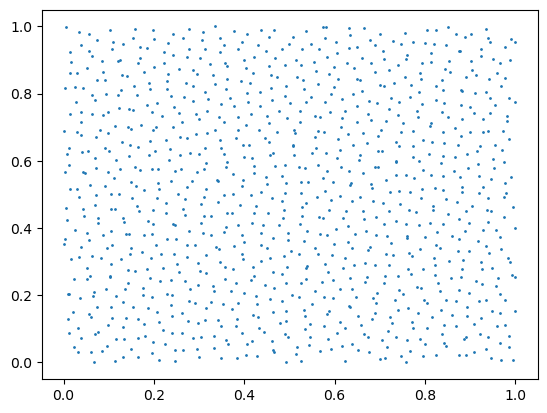

In [510]:
plt.scatter(points[:,0],points[:,1],s=1)

In [511]:
spectrum = spectrum_nd.power_spectrum(points,size=32)

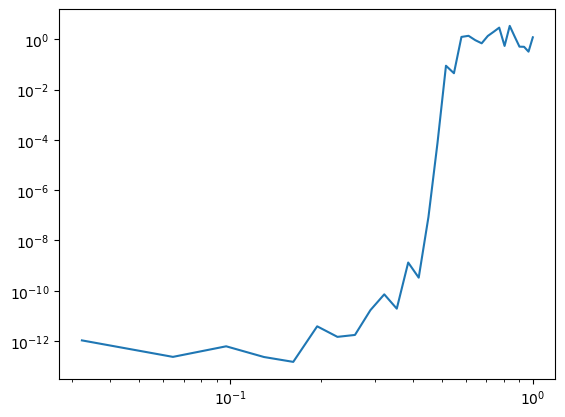

In [512]:
frequencies = [np.sqrt(2*i**2) for i in range(1,32)]
frequencies = frequencies/np.max(frequencies)
diagonal_elements = [spectrum[i,i] for i in range(33,64)]
plt.loglog(frequencies,diagonal_elements)

In [493]:
print(min(frequencies))

0.001040582726326743


#### Toroidal Blue Noise in 3D

In [494]:
result = gbn_toroidal_current_2.sample_toroidal_gbn(
    point_count=1000,
    dims=3,
    bounds=[[0,1] for i in range(3)],
    mode="harmonics",
    step_scale=0.04,
    sigma=1,
    iterations=10000,
    seed=1,
)

In [495]:
points = result.points

In [496]:
spectrum = spectrum_nd.power_spectrum(points,size=32)

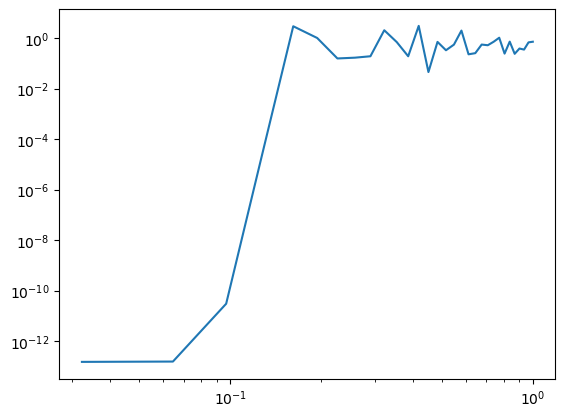

In [503]:
frequencies = [np.sqrt(3*i**2) for i in range(1,32)]
frequencies = frequencies/np.max(frequencies)
diagonal_elements = [spectrum[i,i,i] for i in range(33,64)]
plt.loglog(frequencies,diagonal_elements)

#### Toroidal Blue Noise in 4D

In [504]:
result = gbn_toroidal_current_2.sample_toroidal_gbn(
    point_count=1000,
    dims=4,
    bounds=[[0,1] for i in range(4)],
    mode="harmonics",
    step_scale=0.04,
    sigma=1,
    iterations=10000,
    seed=1,
)

In [505]:
points = result.points

In [506]:
spectrum = spectrum_nd.power_spectrum(points,size=32)

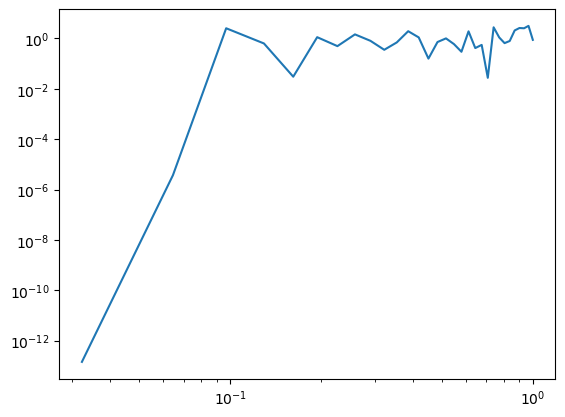

In [507]:
frequencies = [np.sqrt(4*i**2) for i in range(1,32)]
frequencies = frequencies/np.max(frequencies)
diagonal_elements = [spectrum[i,i,i,i] for i in range(33,64)]
plt.loglog(frequencies,diagonal_elements)

#### Comments about 2D and 3D Blue Noise

1. Quality appears to decrease as dimension increases, which is not what is shown in their paper
    - This could be because the codex code is not correct
    - Alternatively, this could be because we are using a bounded domain instead of a toroidal domain

2. The time complexity of generating Gaussian Blue Noise is $O(dn^2)$ (linear in number of dimensions but quadratic in number of points)

#### Alternative 1: Poisson Disk Sampling

If we set $r = n^{-\frac{1}{d}}$, then the points roughly cover the space without leaving large unsampled gaps.

Time complexity is $O(n)$ with the number of samples.

Investigate time complexity with dimension by plotting runtime and dimension:

In [95]:
dimensions = [2,3,4,5,6,7,8,9,10]
n = 1700
runtimes = []

for dimension in dimensions:
    start_time = time.time()
    radius = n**(-1/dimension)
    engine = qmc.PoissonDisk(d=dimension, radius=radius, seed=1)
    sample = engine.random(n)
    end_time = time.time()
    runtimes.append(end_time-start_time)

In [114]:
coefs = np.polyfit(dimensions[2:],np.log(runtimes[2:]),deg=1)
extended_dimensions = [4,5,6,7,8,9,10,11,12,13,14,15]
y = [coefs[1] + coefs[0]*dimension for dimension in extended_dimensions]

Text(0, 0.5, '$\\log(t)$')

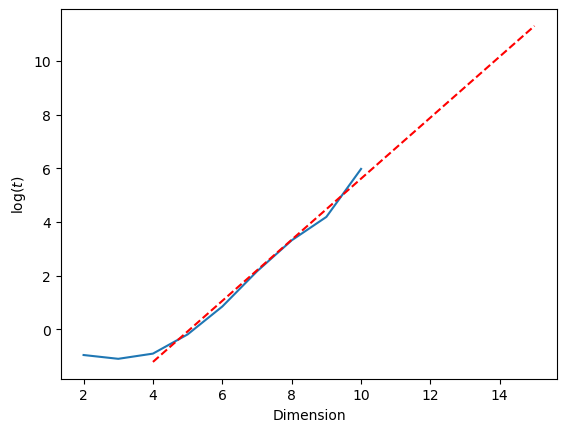

In [115]:
plt.plot(dimensions,np.log(runtimes))
plt.plot(extended_dimensions,y,color="red",linestyle="--")
plt.xlabel("Dimension")
plt.ylabel(r"$\log(t)$")

This graph shows that for $d \geq 4$, runtime is exponential with number of dimensions, which makes this method too expensive to use for high-dimensional problems. For example, for dimension 15, according to the graph, it would take approximately $e^{11}$ seconds $\approx 16$ hours to generate a single point set of 1000 samples (we ideally want orders of millions).

It could feasibly be used to count linear regions in up to roughly 10 dimensions, but beyond that it would be too expensive to run the required experiments.

#### Alternative 2: Halton Sequences

- Low discrepancy sequences have many of the same spatial uniformity properties as hyperuniform point processes such as Blue Noise, but they are much cheaper to generate, and can be randomised by scrambling.
- The Sobol Sequence has computational cost $O(nd)$ however you need the number of points to be a power of 2 to maintain the uniformity properties
- Halton Sequences have computational cost $O(dn\log n)$, which is higher than the Sobol sequence, but using any number of points retains the properties of the sequence, and for any Halton Sequence, any subsequence of consecutive points is also a Halton Sequence, so we can generate point sets by sequentially adding points instead of repeating the optimisation with different numbers of points, as we would have to with point processes. This makes it less expensive to sample more points if we need them, whereas otherwise we would need to use a series of fixed budgets.

In [155]:
sampler = qmc.Halton(d=2, scramble=True,seed=100)
sample = sampler.random(n=1000)

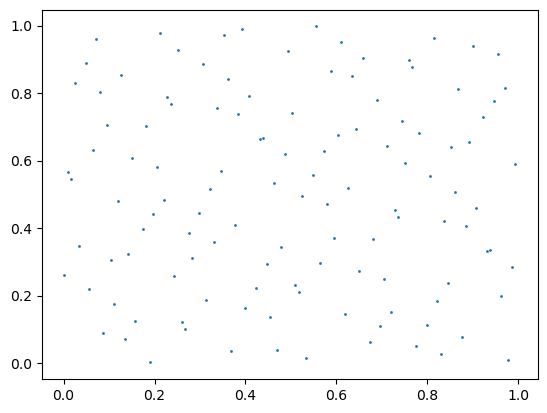

In [163]:
plt.scatter(sample[:,0][:120],sample[:,1][:120],s=1)